In [209]:
!pip install numpy matplotlib scikit-learn pandas openpyxl
!pip install --upgrade pip


In [210]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [211]:
#file = pd.read_excel("/home/edu/projetos/rede-neural/datasets/tabela_distancia_consumo.xlsx").to_numpy()
#
#valor = file[:, 0]
#rotulo = file[:, 1]

valor = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
rotulo = np.array([3, 6, 9, 12, 15, 18, 21, 24, 27, 30])
valor, rotulo

(array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10]),
 array([ 3,  6,  9, 12, 15, 18, 21, 24, 27, 30]))

In [212]:
def calcularPrevisao(w, x, b):
    return w * x + b


def loss(Y, y):
    return Y - y


def correcaoW(w, a, erro, x):
    return w - (a * erro * x)


def correcaoB(b, a, erro):
    return b - (a * erro)


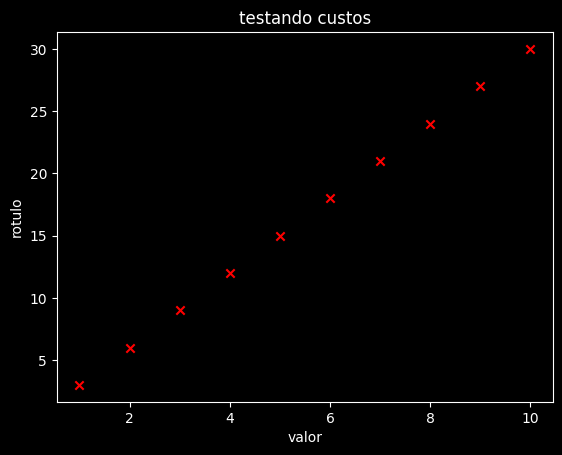

In [213]:
plt.scatter(valor, rotulo, marker='x', c='r')
plt.title('testando custos')
plt.ylabel('rotulo')
plt.xlabel('valor')
plt.show()

In [244]:
def modelo(x, y, w, b, taxa_aprendizado = 0.01):
    m = x.shape[0]
    f_wb = np.zeros(m)
    generation = m / 10

    for gen in range(generation):
        f_wb = np.zeros(m)
        somatorio_erro_w = 0
        somatorio_erro_b = 0

        for i in range(m):
            f_wb[i] = w * x[i] + b

        for i in range(m):
            somatorio_erro_w += (f_wb[i] - y[i]) * 2

        for i in range(m):
            somatorio_erro_b += (f_wb[i] - y[i]) * 2

        for i in range(m):
            media_erro_w = (somatorio_erro_w / m ) * x[i]

        media_erro_b = somatorio_erro_b / m

        print(f"{media_erro_w:.1f}")
        print(f"{media_erro_b:.1f}")
        w = w - (taxa_aprendizado * media_erro_w)
        b = b - (taxa_aprendizado * media_erro_b)
        print(f"{w:.2f}")
        print(f"{b:.2f}")


    return f_wb


f_wb_calculado = modelo(valor, rotulo, 0, 0)
f_wb_calculado


-231.0
-33.0
23100.00
3300.00
1814769.0
260667.0
-181453800.00
-26063400.00
-14258640231.0
-2048118633.0
1425682569300.00
204785799900.00
112030201634769.0
16092079862067.0
-11201594480907600.00
-1609003200406800.00
-880221810234360192.0
-126435545690797232.0
88010979428955111424.00
12641945565879316480.00
6915906817254216433664.0
993404664850265014272.0
-691502670745992609923072.00
-99327824539460617371648.00
-54338311717375492889772032.0
-7805185027284839876788224.0
5433139669066804083822690304.00
780419174903944528101638144.00
426936365442087222624726810624.0
61325374709542729030450544640.0
-42688203404539654406156230590464.00
-6131757051779369083586400485376.00
-3354440989719126412038783234998272.0
-481833751553494929879491896410112.0
335401410768508078491042075132297216.00
48177243398297715928086312174747648.00
26355858306556399270979058617076940800.0
3785770005250184682639260998705348608.0
-2635250429244871291072797924383111774208.00
-378528823281620142093895279861376745472.00
-2

array([3.43893929e+74, 6.44594991e+74, 9.45296053e+74, 1.24599712e+75,
       1.54669818e+75, 1.84739924e+75, 2.14810030e+75, 2.44880136e+75,
       2.74950243e+75, 3.05020349e+75])

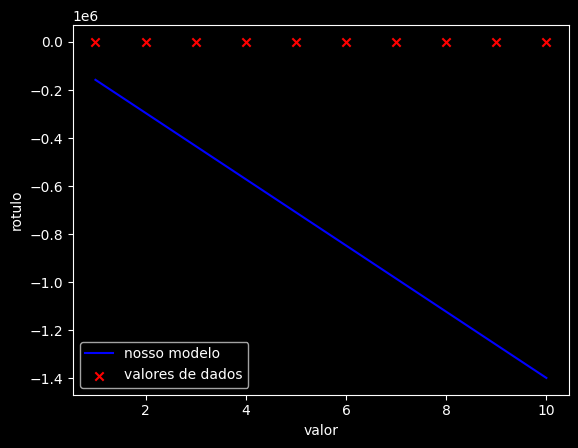

In [215]:
plt.plot(valor, f_wb_calculado, c='b', label='nosso modelo')
plt.scatter(valor, rotulo, marker='x', c='r', label='valores de dados')

plt.ylabel('rotulo')
plt.xlabel('valor')
plt.legend()
plt.show()


In [216]:
def calcular_custo(tamanho, previsao, valorReal):
    custo_somado = 0
    for i in range(tamanho):
        custo_somado += (previsao[i] - valorReal[i]) ** 2

    custo_final = custo_somado / (2 * tamanho)
    return custo_final


custo = calcular_custo(m, f_wb_calculado, rotulo)
f_wb_calculado_com_custo = f_wb_calculado.copy()

for i in range(m):
    f_wb_calculado_com_custo[i] -= custo

plt.plot(valor, f_wb_calculado_com_custo, c='b', label='nosso modelo')
plt.scatter(valor, rotulo, marker='x', c='r', label='valores de dados')

plt.ylabel('rotulo')
plt.xlabel('valor')
plt.legend()
plt.show()

print(f_wb_calculado)
print()
print(f_wb_calculado_com_custo)



IndexError: index 10 is out of bounds for axis 0 with size 10

In [ ]:
#IA
def treinar_modelo(x, y_real, w, b, alpha, epocas):
    m = len(x)

    for epoca in range(epocas):
        soma_dw = 0
        soma_db = 0

        # 1. Acumula o gradiente para todos os dados
        for i in range(m):
            previsao = w * x[i] + b
            erro = previsao - y_real[i]

            soma_dw += erro * x[i]
            soma_db += erro

        # 2. Calcula a média do gradiente (as derivadas)
        dj_dw = soma_dw / m
        dj_db = soma_db / m

        # 3. Atualiza os pesos (Regra da sua imagem)
        w = w - (alpha * dj_dw)
        b = b - (alpha * dj_db)

        # Opcional: imprimir o custo a cada 100 iterações para ver se está caindo
    return w, b

In [ ]:
w_novo, b_novo = treinar_modelo(valor, rotulo, w, b, 0.1, 300)
w_novo = w_novo.item()
b_novo = b_novo.item()

novo_modelo = modelo(valor, w_novo, b_novo)
plt.plot(valor, novo_modelo, c='b', label='nosso modelo')
plt.scatter(valor, rotulo, marker='x', c='r', label='valores de dados')

plt.ylabel('rotulo')
plt.xlabel('valor')
plt.legend()
plt.show()



In [ ]:
w_novo * 900 + b_novo